In [1]:
import numpy as np
from ase.build import bulk

import abtem

abtem.config.set({"diagnostics.progress_bar": False});

(appendix:ensembles)=
# Ensembles

Many of the key objects in *ab*TEM carry two kinds of axes: a set of *base axes* that are necessary to describe the
object — for example, the $x$ and $y$ axes of a wave function — and any number of additional *ensemble axes*, which
describe a collection of such objects with different parameters. A defocus series, the atomic configurations of a
[thermal ensemble](walkthrough:frozen_phonons), the positions of a probe scan, and the samples of a
[partially coherent source](tutorials:partial_coherence) are all ensemble axes, and they are the common machinery
behind most of *ab*TEM's "vary a parameter" workflows.

The simplest way to create an ensemble is to hand an array of values to a parameter that would normally be a single
number:

In [2]:
probe = abtem.Probe(
    energy=100e3, extent=20, gpts=256, semiangle_cutoff=30, defocus=np.linspace(0, 200, 5)
)

waves = probe.build()

print(f"ensemble shape: {waves.ensemble_shape}, base shape: {waves.base_shape}")

waves.axes_metadata

ensemble shape: (5,), base shape: (256, 256)


type           label    coordinates
-------------  -------  ------------------------
ParameterAxis  C10 [Å]  -0.00 -50.00 ... -200.00
RealSpaceAxis  x [Å]    0.00 0.08 ... 19.92
RealSpaceAxis  y [Å]    0.00 0.08 ... 19.92

The wave functions gained a leading `ParameterAxis`, and its coordinates are recorded in the axes metadata (the
defocus appears as the aberration coefficient $C_{10} = -\Delta f$, following the [conventions](appendix:conventions)).
Ensemble axes always precede the base axes in the shape of an object, and they follow the object through every
operation — including into visualizations, where an ensemble axis can be browsed interactively, exploded into a grid
of panels, or [animated](examples:animations):

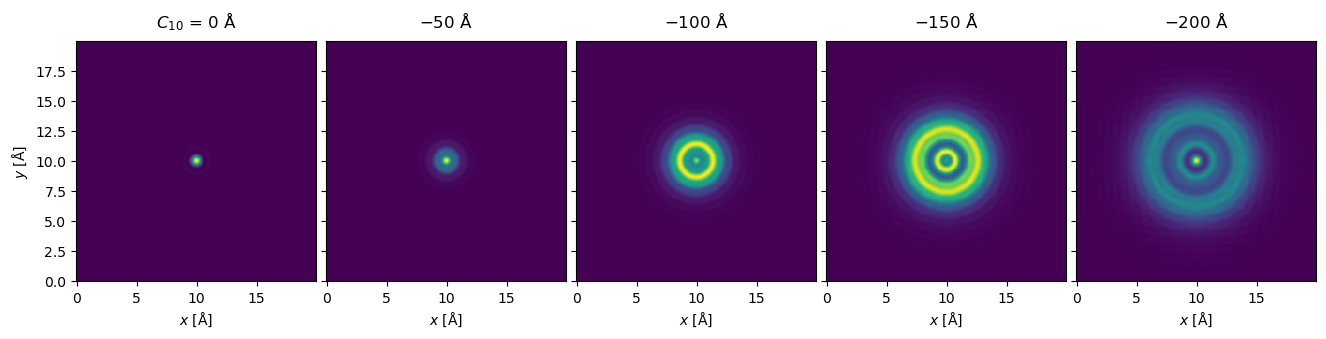

In [3]:
waves.intensity().compute().show(explode=True, figsize=(14, 4), cbar=False);

## Distributions

A plain array gives every ensemble member equal importance. The {py:obj}`abtem.distributions` module creates
parameter distributions that also carry *weights*:

* {py:obj}`abtem.distributions.uniform` — evenly spaced values with uniform weights;
* {py:obj}`abtem.distributions.from_values` — arbitrary user-defined values and weights;
* {py:obj}`abtem.distributions.gaussian` — values weighted by a (possibly multidimensional) Gaussian, as used for
  example to model focal spread.

For example, a Gaussian defocus distribution:

In [4]:
distribution = abtem.distributions.gaussian(
    center=-100, standard_deviation=50, num_samples=5, ensemble_mean=True
)

for value, weight in zip(np.array(distribution.values), distribution.weights):
    print(f"defocus: {value:7.1f} Å, weight: {weight:.3f}")

defocus:  -250.0 Å, weight: 0.010
defocus:  -175.0 Å, weight: 0.295
defocus:  -100.0 Å, weight: 0.909
defocus:   -25.0 Å, weight: 0.295
defocus:    50.0 Å, weight: 0.010


## Reducing an ensemble

The `ensemble_mean` flag above does not change the values — it *tags* the axis for reduction. Whenever the ensemble
is reduced — explicitly, by calling {py:obj}`abtem.waves.reduce_ensemble`, or automatically, when a detector
integrates the signal during a scan — a weighted average is taken over every axis tagged with `ensemble_mean=True`,
while untagged axes survive into the measurement so that each member can be inspected separately.

The difference is easy to see in a STEM simulation with a focal-spread distribution: with `ensemble_mean=True` the
defocus axis is averaged away during detection, while with `ensemble_mean=False` it remains as an axis of the
measurement:

In [5]:
atoms = bulk("Si", "diamond", a=5.43, cubic=True) * (2, 2, 4)
potential = abtem.Potential(atoms, sampling=0.1, slice_thickness=2)
detector = abtem.FlexibleAnnularDetector()

for ensemble_mean in (True, False):
    focal_spread = abtem.distributions.gaussian(
        center=0, standard_deviation=50, num_samples=5, ensemble_mean=ensemble_mean
    )
    probe = abtem.Probe(energy=100e3, semiangle_cutoff=30, defocus=focal_spread)

    measurement = probe.scan(potential, detectors=detector)

    print(f"ensemble_mean={ensemble_mean!s:>5}: measurement shape {measurement.shape}")

ensemble_mean= True: measurement shape (36, 36, 122, 1)
ensemble_mean=False: measurement shape (5, 36, 36, 122, 1)


(Both measurements above are lazy — the shapes are known before anything is computed.)

## Multidimensional ensembles

When several parameters are given as distributions, the ensemble becomes their outer product, adding one axis per
parameter:

In [6]:
ctf = abtem.CTF(energy=100e3, defocus=np.linspace(0, 100, 4), Cs=np.linspace(0, 1e5, 3))

print(f"ensemble shape: {ctf.ensemble_shape}")

ctf.axes_metadata

ensemble shape: (4, 3)


type           label    coordinates
-------------  -------  ------------------------
ParameterAxis  C10 [Å]  -0.00 -33.33 ... -100.00
ParameterAxis  C30 [Å]  0.00 50000.00 100000.00

A two-parameter series like this computes $4 \times 3 = 12$ contrast transfer functions in a single, fully
parallel calculation.

## Parallelization over ensembles

Each member of an ensemble is independent, which allows for trivial parallelization: *ab*TEM groups the ensemble
into batches that map onto the chunks of the underlying Dask arrays, and Dask distributes them over the available
resources (see the [parallelization walkthrough](walkthrough:parallelization)). The batch size is controlled by the
`dask.chunk-size` configuration option, as described in the
[performance tips](appendix:performance_tips:batch_size).

The partitioning of an ensemble into Dask blocks can be inspected directly:

In [7]:
ctf.ensemble_blocks(2)

dask.array<partial_transform, shape=(4, 3), dtype=object, chunksize=(2, 1), chunktype=numpy.ndarray>